In [ ]:
!pip -q install insightface onnxruntime opencv-python numpy matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 7.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 82.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from insightface.app import FaceAnalysis

Init InsightFace

In [ ]:
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=-1, det_size=(640,640))

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:05<00:00, 56242.51KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


In [ ]:
INPUT_DIR = "/content/drive/MyDrive/Mirror Vision-KARIGOR/Dataset_Mirror_SPLIT/personA"
OUT_DIR = "/content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF"
os.makedirs(OUT_DIR, exist_ok=True)

def list_images(folder):
    exts = (".jpg",".jpeg",".png",".webp")
    out=[]
    for root,_,fs in os.walk(folder):
        for f in fs:
            if f.lower().endswith(exts):
                out.append(os.path.join(root,f))
    return sorted(out)

imgs = list_images(INPUT_DIR)
print("Total:", len(imgs))

Total: 44


ROI builder (bbox + 5 landmarks)

In [ ]:
def clamp(v, lo, hi): return max(lo, min(hi, v))

def roi_boxes_from_face(img, face):
    h, w = img.shape[:2]
    x1,y1,x2,y2 = face.bbox.astype(int)
    x1=clamp(x1,0,w-1); x2=clamp(x2,0,w-1)
    y1=clamp(y1,0,h-1); y2=clamp(y2,0,h-1)

    # landmarks (5 points): left eye, right eye, nose, left mouth, right mouth
    k = face.kps.astype(int)
    le, re, nose, lm, rm = k[0], k[1], k[2], k[3], k[4]

    bw = x2 - x1
    bh = y2 - y1

    # Forehead: top 25% of face bbox
    fh_y2 = y1 + int(0.28*bh)
    forehead = (x1, y1, x2, fh_y2)

    # Under-eye: band under eyes (each side)
    eye_y = int((le[1]+re[1])/2)
    ue_y1 = clamp(eye_y + int(0.03*bh), 0, h-1)
    ue_y2 = clamp(eye_y + int(0.18*bh), 0, h-1)

    left_undereye  = (x1, ue_y1, x1 + int(0.50*bw), ue_y2)
    right_undereye = (x1 + int(0.50*bw), ue_y1, x2, ue_y2)

    # Lips: centered at mouth corners
    mouth_cx = int((lm[0]+rm[0])/2)
    mouth_cy = int((lm[1]+rm[1])/2)
    lip_w = int(0.55*bw)
    lip_h = int(0.22*bh)
    lips = (clamp(mouth_cx - lip_w//2,0,w-1),
            clamp(mouth_cy - lip_h//2,0,h-1),
            clamp(mouth_cx + lip_w//2,0,w-1),
            clamp(mouth_cy + lip_h//2,0,h-1))

    # Cheeks: mid bands
    cy1 = y1 + int(0.35*bh)
    cy2 = y1 + int(0.70*bh)
    left_cheek  = (x1, cy1, x1 + int(0.45*bw), cy2)
    right_cheek = (x1 + int(0.55*bw), cy1, x2, cy2)

    # Jawline band: bottom 25%
    jaw = (x1, y1 + int(0.72*bh), x2, y2)

    return {
        "forehead": forehead,
        "left_undereye": left_undereye,
        "right_undereye": right_undereye,
        "lips": lips,
        "left_cheek": left_cheek,
        "right_cheek": right_cheek,
        "jaw": jaw
    }

def crop_box(img, box):
    x1,y1,x2,y2 = box
    if x2<=x1 or y2<=y1:
        return None
    return img[y1:y2, x1:x2].copy()

Overlay preview on one image

faces: 1


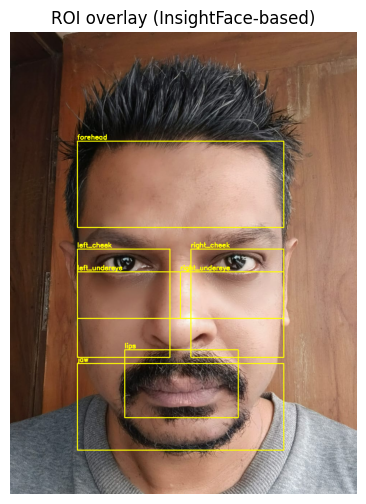

In [ ]:
def show(img_bgr, title=""):
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off")
    plt.show()

p = imgs[0]
img = cv2.imread(p)
faces = app.get(img)
print("faces:", len(faces))
f = faces[0]

boxes = roi_boxes_from_face(img, f)
vis = img.copy()
for name, (x1,y1,x2,y2) in boxes.items():
    cv2.rectangle(vis, (x1,y1), (x2,y2), (0,255,255), 2)
    cv2.putText(vis, name, (x1, max(0,y1-5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,255), 2)

show(vis, "ROI overlay (InsightFace-based)")

Batch export crops + json

In [ ]:
OUT_CROPS = os.path.join(OUT_DIR, "crops")
OUT_JSON  = os.path.join(OUT_DIR, "json")
os.makedirs(OUT_CROPS, exist_ok=True)
os.makedirs(OUT_JSON, exist_ok=True)

fail=[]
ok=0

for p in tqdm(imgs[:50]):  # demo 50, পরে সব
    img = cv2.imread(p)
    if img is None:
        fail.append((p,"read_failed")); continue
    faces = app.get(img)
    if len(faces)!=1:
        fail.append((p,f"faces={len(faces)}")); continue

    f = faces[0]
    boxes = roi_boxes_from_face(img, f)

    base = os.path.splitext(os.path.basename(p))[0]
    crop_dir = os.path.join(OUT_CROPS, base)
    os.makedirs(crop_dir, exist_ok=True)

    meta = {"image": p, "boxes": {}}
    for name, box in boxes.items():
        crop = crop_box(img, box)
        if crop is not None and crop.size>0:
            cv2.imwrite(os.path.join(crop_dir, f"{name}.jpg"), crop)
            meta["boxes"][name] = [int(x) for x in box]

    with open(os.path.join(OUT_JSON, base+".json"), "w", encoding="utf-8") as fjson:
        json.dump(meta, fjson, ensure_ascii=False, indent=2)

    ok+=1

print("OK:", ok, "Fail:", len(fail))
print("Out:", OUT_DIR)

100%|██████████| 44/44 [01:59<00:00,  2.72s/it]

OK: 44 Fail: 0
Out: /content/drive/MyDrive/Mirror Vision-KARIGOR/MirrorVision_ROI_Output_IF
